# 作业三

## 2 卷积和池化层
### 2.1 理论计算题

输入一张大小为 $3 \times 32 \times 32$（通道数 $\times$ 高 $\times$ 宽）的彩色图像，通过一个卷积层，该层包含 $16$ 个卷积核，每个卷积核大小为 $3 \times 5 \times 5$。设置填充（Padding）为 $2$，步长（Stride）为 $2$。

**1. 请计算该卷积层输出的特征图（Feature Map）的维度（通道数 $\times$ 高 $\times$ 宽）。**

输出通道数 $C_{out} = 16$（卷积核个数）。

输出高度：
$$H_{out} = \left\lfloor \frac{H_{in} + 2 \times P - K_H}{S} \right\rfloor + 1 = \left\lfloor \frac{32 + 2 \times 2 - 5}{2} \right\rfloor + 1 = \left\lfloor \frac{31}{2} \right\rfloor + 1 = 15 + 1 = 16$$

输出宽度同理：
$$W_{out} = \left\lfloor \frac{32 + 2 \times 2 - 5}{2} \right\rfloor + 1 = 16$$

因此输出特征图维度为：**$16 \times 16 \times 16$**（通道数 $\times$ 高 $\times$ 宽）。

**2. 计算这个卷积操作中，单个输出通道上的一个像素值，需要对输入进行多少次乘加（乘法）操作？**

每个卷积核覆盖 $3$ 个输入通道，每个通道的卷积核尺寸为 $5 \times 5$。对于单个输出通道上的一个像素值，需要：
$$3 \times 5 \times 5 = 75 \text{ 次乘加操作}$$

即每个输出像素由 $75$ 个权重与对应输入的乘积求和得到。

### 2.2 编程题

不使用深度学习框架的池化 API（如 `torch.nn.MaxPool2d`），而使用 Python 和 NumPy（或 PyTorch 基础张量操作），手动实现一个支持步长（stride）和填充（padding）的二维最大池化（Max Pooling）前向传播函数。

In [1]:
import torch
import numpy as np

def max_pool2d(X, pool_size, stride=None, padding=0):
    """
    手动实现二维最大池化前向传播。

    参数：
        X: 输入张量，形状 (N, C, H, W) 或 (C, H, W)
        pool_size: 池化窗口大小，int 或 (pH, pW)
        stride: 步长，int 或 (sH, sW)，默认等于 pool_size
        padding: 填充大小，int 或 (pH, pW)

    返回：
        pooled: 池化后的输出张量
    """
    # 统一输入为 4D
    if X.dim() == 3:
        X = X.unsqueeze(0)
    elif X.dim() != 4:
        raise ValueError(f'期望输入为 3D 或 4D 张量，实际为 {X.dim()}D')

    N, C, H, W = X.shape

    # 统一参数格式
    if isinstance(pool_size, int):
        pH = pW = pool_size
    else:
        pH, pW = pool_size

    if stride is None:
        sH, sW = pH, pW
    elif isinstance(stride, int):
        sH = sW = stride
    else:
        sH, sW = stride

    if isinstance(padding, int):
        padH = padW = padding
    else:
        padH, padW = padding

    # 计算输出尺寸
    H_out = (H + 2 * padH - pH) // sH + 1
    W_out = (W + 2 * padW - pW) // sW + 1

    # 对输入进行填充（用 -inf 保证不影响 max 结果）
    if padH > 0 or padW > 0:
        X_padded = torch.full((N, C, H + 2 * padH, W + 2 * padW),
                              float('-inf'), dtype=X.dtype, device=X.device)
        X_padded[:, :, padH:padH + H, padW:padW + W] = X
    else:
        X_padded = X.float()

    # 初始化输出
    pooled = torch.empty((N, C, H_out, W_out), dtype=X_padded.dtype, device=X.device)

    # 逐窗口取最大值
    for i in range(H_out):
        for j in range(W_out):
            h_start = i * sH
            h_end = h_start + pH
            w_start = j * sW
            w_end = w_start + pW
            window = X_padded[:, :, h_start:h_end, w_start:w_end]
            # 在最后两个维度取 max
            pooled[:, :, i, j] = window.max(dim=-1).values.max(dim=-1).values

    return pooled

In [2]:
# 测试：与 PyTorch 内置 MaxPool2d 对比
torch.manual_seed(42)
X = torch.randn(2, 3, 8, 8)  # N=2, C=3, H=8, W=8

# 手动实现
out_manual = max_pool2d(X, pool_size=2, stride=2, padding=0)

# PyTorch 内置
pool = torch.nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
out_torch = pool(X)

print(f'输入形状: {X.shape}')
print(f'手动实现输出形状: {out_manual.shape}')
print(f'PyTorch 内置输出形状: {out_torch.shape}')
print(f'结果一致: {torch.allclose(out_manual.float(), out_torch.float())}')

输入形状: torch.Size([2, 3, 8, 8])
手动实现输出形状: torch.Size([2, 3, 4, 4])
PyTorch 内置输出形状: torch.Size([2, 3, 4, 4])
结果一致: True


In [3]:
# 测试带 padding 的情况
X2 = torch.randn(1, 2, 5, 5)
out_manual2 = max_pool2d(X2, pool_size=3, stride=2, padding=1)
pool2 = torch.nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
out_torch2 = pool2(X2)

print(f'输入形状: {X2.shape}')
print(f'手动实现输出形状: {out_manual2.shape}')
print(f'PyTorch 内置输出形状: {out_torch2.shape}')
print(f'结果一致: {torch.allclose(out_manual2.float(), out_torch2.float())}')

输入形状: torch.Size([1, 2, 5, 5])
手动实现输出形状: torch.Size([1, 2, 3, 3])
PyTorch 内置输出形状: torch.Size([1, 2, 3, 3])
结果一致: True


## 3 LeNet, AlexNet, VGG 和 NiN
### 3.1 理论计算题

在 VGG 网络中，作者主张使用多个 $3 \times 3$ 卷积核级联来替代较大的卷积核（如 $5 \times 5$ 或 $7 \times 7$）。假设输入和输出的特征图通道数均为 $C$。

**1. 计算一个 $5 \times 5$ 卷积层（不带偏置）的参数量。**

对于输入通道数为 $C$、输出通道数为 $C$、卷积核大小为 $5 \times 5$ 且无偏置的卷积层：
$$\text{参数量} = C \times C \times 5 \times 5 = 25C^2$$

**2. 计算两个依次级联的 $3 \times 3$ 卷积层（不带偏置，两层通道数均为 $C$）的总参数量。**

第一层 $3 \times 3$ 卷积（$C \to C$）：$C \times C \times 3 \times 3 = 9C^2$

第二层 $3 \times 3$ 卷积（$C \to C$）：$C \times C \times 3 \times 3 = 9C^2$

总参数量：$9C^2 + 9C^2 = 18C^2$

**对比：** $25C^2$ vs $18C^2$，两个 $3 \times 3$ 卷积级联不仅参数量更少（$18/25 = 72\%$），还拥有更大的感受野（等价于 $5 \times 5$），同时引入了更多的非线性变换。

### 3.2 编程题

NiN 网络核心的创新是引入了「1x1 卷积」组成的 NiN 块来替代传统的全连接层，以减少参数量。请使用 PyTorch（`torch.nn.Sequential`）定义一个标准的 NiN 块（NiN Block）。

要求：NiN 块接收输入通道数 `in_channels` 和输出通道数 `out_channels`，并由一个普通的卷积层（指定卷积核大小 `kernel_size`，步长 `stride`，填充 `padding`）以及两个随后的 1x1 卷积层级联组成。每层卷积后都需要跟一个 ReLU 激活层。

In [4]:
import torch
import torch.nn as nn

def nin_block(in_channels, out_channels, kernel_size, stride=1, padding=0):
    """
    构建一个标准的 NiN 块。

    结构：普通卷积层 + ReLU + 1x1 卷积 + ReLU + 1x1 卷积 + ReLU

    参数：
        in_channels: 输入通道数
        out_channels: 输出通道数
        kernel_size: 第一层卷积的卷积核大小
        stride: 步长
        padding: 填充

    返回：
        nn.Sequential 封装的 NiN 块
    """
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding),
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1),
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1),
        nn.ReLU()
    )

In [5]:
# 测试 NiN 块
block = nin_block(in_channels=3, out_channels=16, kernel_size=5, stride=1, padding=2)
print(block)

# 测试前向传播
x = torch.randn(2, 3, 32, 32)
y = block(x)
print(f'\n输入形状: {x.shape}')
print(f'输出形状: {y.shape}')

# 统计参数量
total_params = sum(p.numel() for p in block.parameters())
print(f'总参数量: {total_params}')

Sequential(
  (0): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (1): ReLU()
  (2): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
  (3): ReLU()
  (4): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
  (5): ReLU()
)

输入形状: torch.Size([2, 3, 32, 32])
输出形状: torch.Size([2, 16, 32, 32])
总参数量: 1760


## 4 Inception, 批量归一化和残差网络
### 4.1 理论计算题

在一个小批量（Mini-batch）训练中，某一个通道内某一特定空间位置的特征值在 4 个样本上的输出分别为：$x_1 = 2, x_2 = 4, x_3 = 6, x_4 = 8$。假设当前批量归一化层学到的缩放参数 $\gamma = 2$，偏移参数 $\beta = 1$，常数 $\epsilon = 0$。

请计算这 4 个样本经由该 Batch Normalization 层后的最终输出值 $y_1, y_2, y_3, y_4$。

**步骤 1：计算均值 $\mu$**
$$\mu = \frac{2 + 4 + 6 + 8}{4} = 5$$

**步骤 2：计算方差 $\sigma^2$**
$$\sigma^2 = \frac{(2-5)^2 + (4-5)^2 + (6-5)^2 + (8-5)^2}{4} = \frac{9 + 1 + 1 + 9}{4} = 5$$

**步骤 3：标准化 $\hat{x}_i = \frac{x_i - \mu}{\sqrt{\sigma^2 + \epsilon}}$**
$$\hat{x}_1 = \frac{2 - 5}{\sqrt{5}} = -\frac{3}{\sqrt{5}},\quad \hat{x}_2 = -\frac{1}{\sqrt{5}},\quad \hat{x}_3 = \frac{1}{\sqrt{5}},\quad \hat{x}_4 = \frac{3}{\sqrt{5}}$$

**步骤 4：缩放和偏移 $y_i = \gamma \cdot \hat{x}_i + \beta$**
$$y_1 = 2 \times \left(-\frac{3}{\sqrt{5}}\right) + 1 = 1 - \frac{6}{\sqrt{5}} \approx -1.683$$
$$y_2 = 2 \times \left(-\frac{1}{\sqrt{5}}\right) + 1 = 1 - \frac{2}{\sqrt{5}} \approx 0.106$$
$$y_3 = 2 \times \frac{1}{\sqrt{5}} + 1 = 1 + \frac{2}{\sqrt{5}} \approx 1.894$$
$$y_4 = 2 \times \frac{3}{\sqrt{5}} + 1 = 1 + \frac{6}{\sqrt{5}} \approx 3.683$$

### 4.2 编程题

残差网络（ResNet）通过引入跨层连接（残差连接）解决了深层网络的梯度消失问题。请使用 PyTorch 自定义一个残差块类 `Residual`。

要求：该块包含两个具有相同输出通道数的 $3 \times 3$ 卷积层，每个卷积层后跟一个批量归一化层。如果 `use_1x1conv=True`，则需要对输入应用一个 $1 \times 1$ 的卷积层来调整输入的通道数和形状，以便其能和卷积块的输出进行按元素相加（$f(x) + x$）。

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class Residual(nn.Module):
    """
    ResNet 残差块。

    包含两个 3×3 卷积层，每个后跟 BatchNorm。
    若输入输出通道数或空间尺寸不匹配，通过 1×1 卷积调整。

    参数：
        in_channels: 输入通道数
        out_channels: 输出通道数
        use_1x1conv: 是否使用 1×1 卷积调整输入
        stride: 第一层卷积的步长（用于下采样）
    """
    def __init__(self, in_channels, out_channels, use_1x1conv=False, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        if use_1x1conv:
            self.conv_1x1 = nn.Conv2d(in_channels, out_channels,
                                      kernel_size=1, stride=stride)
        else:
            self.conv_1x1 = None

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        identity = self.conv_1x1(x) if self.conv_1x1 is not None else x
        out = F.relu(out + identity)
        return out

In [7]:
# 测试 1：同通道数，无 1x1 卷积
res1 = Residual(in_channels=64, out_channels=64)
x1 = torch.randn(2, 64, 32, 32)
y1 = res1(x1)
print(f'测试 1 - 同通道数残差块：')
print(f'  输入形状: {x1.shape}')
print(f'  输出形状: {y1.shape}')
print(f'  有 1x1 卷积: {res1.conv_1x1 is not None}')

# 测试 2：不同通道数 + 下采样，使用 1x1 卷积
res2 = Residual(in_channels=64, out_channels=128, use_1x1conv=True, stride=2)
x2 = torch.randn(2, 64, 32, 32)
y2 = res2(x2)
print(f'\n测试 2 - 不同通道数 + 下采样残差块：')
print(f'  输入形状: {x2.shape}')
print(f'  输出形状: {y2.shape}')
print(f'  有 1x1 卷积: {res2.conv_1x1 is not None}')

测试 1 - 同通道数残差块：
  输入形状: torch.Size([2, 64, 32, 32])
  输出形状: torch.Size([2, 64, 32, 32])
  有 1x1 卷积: False

测试 2 - 不同通道数 + 下采样残差块：
  输入形状: torch.Size([2, 64, 32, 32])
  输出形状: torch.Size([2, 128, 16, 16])
  有 1x1 卷积: True


## 5 图像增强、微调和样式迁移
### 5.1 理论计算题

**1. 为什么我们通常对除了最终输出层之外的「骨干特征提取层」设置较小的学习率（甚至将其参数冻结/截断），而对新增加的「输出层/分类层」设置较大的学习率？**

骨干网络（Backbone）已经在大规模数据集（如 ImageNet）上学习了通用的视觉表示（边缘、纹理、形状等底层和中间层特征），这些特征是跨任务可迁移的。如果使用较大的学习率微调骨干网络，可能会破坏这些已经学习好的通用特征。因此：
- 对骨干层设置较小学习率或直接冻结，以保留已学到的通用视觉知识；
- 对新增加的分类层设置较大学习率，使其快速适应新任务的具体类别。

**2. 如果目标数据集非常小，且与源数据集非常相似，我们应该采取什么样的微调策略以防止过拟合？**

当目标数据集很小且与源数据集相似时：
- 由于数据量小，从零训练或大幅微调会导致严重过拟合；
- 由于数据分布相似，源任务学到的特征对目标任务高度适用。

因此最佳策略是：**冻结全部骨干网络参数，仅训练新替换的分类层**（输出层）。这样既能充分利用预训练模型的通用特征表示，又能最大程度避免在小数据集上的过拟合。相当于将预训练模型作为固定特征提取器。

### 5.2 编程题

图像增强能有效增强模型泛化的能力。请利用 `torchvision.transforms` 模块创建一个组合图像增强管道（Pipeline）：
1. 随机对图像进行裁剪，使其面积比例在 0.08 到 1.0 之间，并将裁剪后的图像缩放到 $224 \times 224$ 像素；
2. 拥有 50% 的概率对图像进行水平翻转；
3. 随机改变图像的亮度（Brightness）、对比度（Contrast）和饱和度（Saturation），变化范围设为 0.5；
4. 最终将图像转换为 PyTorch 张量（Tensor）。

In [8]:
import zhplot
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# 构建图像增强管道
augmentation_pipeline = transforms.Compose([
    # 1. 随机裁剪（面积比例 0.08~1.0），缩放至 224×224
    transforms.RandomResizedCrop(224, scale=(0.08, 1.0)),
    # 2. 50% 概率水平翻转
    transforms.RandomHorizontalFlip(p=0.5),
    # 3. 随机颜色抖动（亮度、对比度、饱和度各变化 0.5）
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
    # 4. 转换为 Tensor
    transforms.ToTensor()
])

print('图像增强管道已创建：')
print(augmentation_pipeline)

图像增强管道已创建：
Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.5, 1.5), contrast=(0.5, 1.5), saturation=(0.5, 1.5), hue=None)
    ToTensor()
)


/var/folders/l7/1khtwjld5njcrg2xfhzs0bx00000gn/T/ipykernel_1727/2514936665.py:30: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/l7/1khtwjld5njcrg2xfhzs0bx00000gn/T/ipykernel_1727/2514936665.py:30: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/l7/1khtwjld5njcrg2xfhzs0bx00000gn/T/ipykernel_1727/2514936665.py:30: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/l7/1khtwjld5njcrg2xfhzs0bx00000gn/T/ipykernel_1727/2514936665.py:30: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/l7/1khtwjld5njcrg2xfhzs0bx00000gn/T/ipykernel_1727/2514936665.py:30: UserWarning: Glyph 22686 (\N{CJK UNIFIED IDEOGRAPH-589E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/l7/1khtwjld5

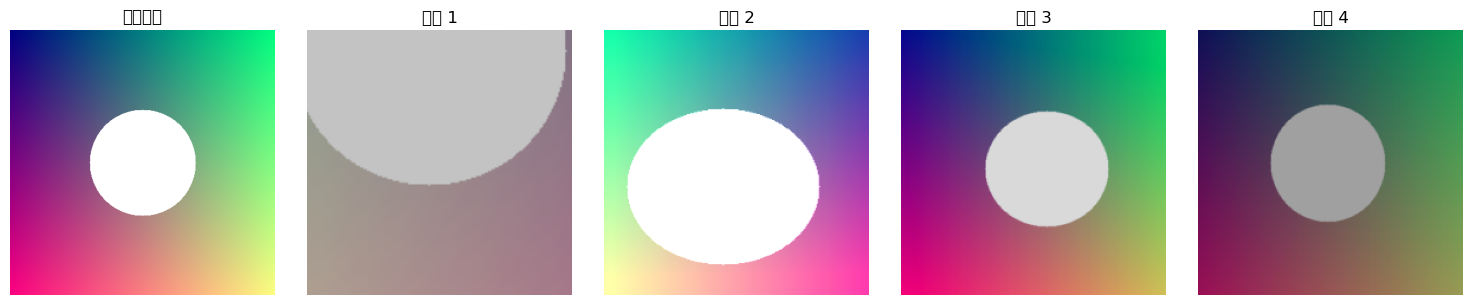

In [9]:
# 可视化：对同一张图多次增强的效果
def visualize_augmentation():
    """生成一张简单的彩色图并展示多次增强效果"""
    # 生成一个简单的测试图像（400x400 的彩色渐变 + 圆）
    img_np = np.zeros((400, 400, 3), dtype=np.uint8)
    for i in range(400):
        for j in range(400):
            img_np[i, j, 0] = int(255 * i / 400)
            img_np[i, j, 1] = int(255 * j / 400)
            img_np[i, j, 2] = int(128)

    # 画一个白色圆
    yy, xx = np.ogrid[:400, :400]
    circle = (xx - 200) ** 2 + (yy - 200) ** 2 <= 80 ** 2
    img_np[circle] = [255, 255, 255]

    img = Image.fromarray(img_np)

    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    axes[0].imshow(img)
    axes[0].set_title('原始图像')
    axes[0].axis('off')

    for i in range(1, 5):
        augmented = augmentation_pipeline(img)
        axes[i].imshow(augmented.permute(1, 2, 0))
        axes[i].set_title(f'增强 {i}')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

visualize_augmentation()

## 6 目标检测、计算机视觉训练流程
### 6.1 理论计算题

在目标检测中，交并比（IoU）用于衡量预测边界框与真实边界框的重合程度。已知图像中两个边界框（以 $[左上角x, 左上角y, 右下角x, 右下角y]$ 方式表示）：
- 真实框（Ground Truth）$A = [10, 10, 50, 50]$
- 预测框（Prediction Box）$B = [30, 30, 70, 70]$

请计算边界框 $A$ 和边界框 $B$ 之间的 IoU 精确值。

**步骤 1：计算各框面积**
$$\text{Area}_A = (50-10) \times (50-10) = 40 \times 40 = 1600$$
$$\text{Area}_B = (70-30) \times (70-30) = 40 \times 40 = 1600$$

**步骤 2：计算交集区域**
$$x_{\text{left}} = \max(10, 30) = 30$$
$$y_{\text{top}} = \max(10, 30) = 30$$
$$x_{\text{right}} = \min(50, 70) = 50$$
$$y_{\text{bottom}} = \min(50, 70) = 50$$

交集面积：$(50-30) \times (50-30) = 20 \times 20 = 400$

**步骤 3：计算并集面积**
$$\text{Area}_{\cup} = 1600 + 1600 - 400 = 2800$$

**步骤 4：计算 IoU**
$$\text{IoU} = \frac{\text{Area}_{\cap}}{\text{Area}_{\cup}} = \frac{400}{2800} = \frac{1}{7} \approx 0.1429$$

### 6.2 编程题

在计算机视觉训练流程中，标签平滑（Label Smoothing）通过防止模型过于自信地预测某些类别来提高泛化性。标准交叉熵使用独热编码（One-hot），若设置平滑因子 $\epsilon = 0.1$，则对于 $K$ 分类问题，真实标签对应的目标概率从 $1$ 变为 $1-\epsilon$，其余错误类别的概率从 $0$ 变为 $\frac{\epsilon}{K-1}$。

请实现一个计算标签平滑后交叉熵损失函数的函数。

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F


def label_smoothing_cross_entropy(logits, labels, epsilon=0.1):
    """
    计算带标签平滑的交叉熵损失。

    参数：
        logits: 模型输出 logits，形状 (N, K)
        labels: 真实类别索引，形状 (N,)
        epsilon: 平滑因子，默认 0.1

    返回：
        loss: 标量损失值
    """
    K = logits.shape[-1]
    log_probs = F.log_softmax(logits, dim=-1)

    # 构建平滑后的目标分布 q
    # q[true] = 1 - epsilon, q[other] = epsilon / (K - 1)
    with torch.no_grad():
        smooth_labels = torch.full_like(log_probs, epsilon / (K - 1))
        smooth_labels.scatter_(1, labels.unsqueeze(1), 1.0 - epsilon)

    # 交叉熵: -sum(q * log(p))
    loss = -torch.sum(smooth_labels * log_probs, dim=-1).mean()
    return loss

In [11]:
# 测试标签平滑交叉熵损失
torch.manual_seed(42)

# 模拟 10 分类，batch_size=8
K = 10
batch_size = 8
logits = torch.randn(batch_size, K)
labels = torch.randint(0, K, (batch_size,))

# 普通交叉熵
loss_ce = F.cross_entropy(logits, labels)
print(f'普通交叉熵损失: {loss_ce.item():.6f}')

# 标签平滑交叉熵（epsilon=0）应与普通交叉熵一致
loss_ls0 = label_smoothing_cross_entropy(logits, labels, epsilon=0.0)
print(f'标签平滑损失 (epsilon=0): {loss_ls0.item():.6f}')
print(f'两者一致: {torch.allclose(loss_ce, loss_ls0)}')

# 标签平滑交叉熵（epsilon=0.1）
loss_ls = label_smoothing_cross_entropy(logits, labels, epsilon=0.1)
print(f'标签平滑损失 (epsilon=0.1): {loss_ls.item():.6f}')

# 验证标签平滑惩罚了过度自信的预测
# 极端情况：模型对正确类别预测概率非常接近 1
logits_confident = torch.full((1, K), -10.0)  # 所有类别初始概率都很低
logits_confident[0, labels[0]] = 10.0          # 正确类别 logit 很高

loss_ce_confident = F.cross_entropy(logits_confident, labels[:1])
loss_ls_confident = label_smoothing_cross_entropy(logits_confident, labels[:1], epsilon=0.1)

print(f'\n自信预测 - 普通交叉熵: {loss_ce_confident.item():.6f}')
print(f'自信预测 - 标签平滑:    {loss_ls_confident.item():.6f}')
print(f'标签平滑惩罚了过度自信: {loss_ls_confident > loss_ce_confident}')

普通交叉熵损失: 3.351549
标签平滑损失 (epsilon=0): 3.351549
两者一致: True
标签平滑损失 (epsilon=0.1): 3.285936

自信预测 - 普通交叉熵: 0.000000
自信预测 - 标签平滑:    2.000000
标签平滑惩罚了过度自信: True
